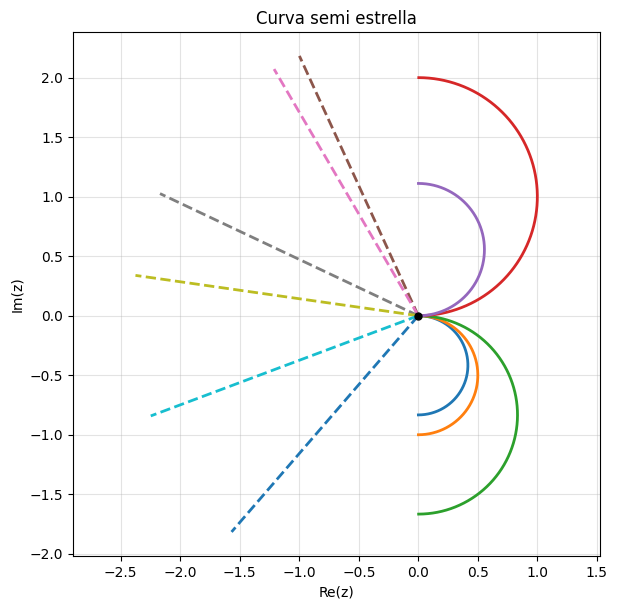

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_star_like(c_list, beta_list,
                         n_arc=20000, n_ray=600,
                         x_min=1e-3, x_max=1e3, r_len=None):
    """
    Dibuja la curva del modelo (1.1).
      - c_list: [c1,...,cs]  (reales ≠ 0)  => arcos  t = 1/(x - i c_k), x>0
      - beta_list: [β_{s+1},...,β_m] con π/2 < β < 3π/2  => rayos t = e^{iβ} x, x≥0
    """

    # ---- Arcos: t = 1/(x - i c_k), x ∈ R_+ ----
    x = np.logspace(np.log10(x_min), np.log10(x_max), n_arc)
    plt.figure(figsize=(6.8, 6.8))
    for ck in c_list:
        z = 1.0 / (x - 1j*ck)
        plt.plot(z.real, z.imag, lw=2, label=fr'arco $c={ck}$')

    # Longitud típica para rayos
    if r_len is None:
        r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))

    # ---- Rayos: t = e^{iβ} x, x ≥ 0 ----
    r = np.linspace(0.0, r_len, n_ray)
    for beta in beta_list:
        z = np.exp(1j*beta) * r
        plt.plot(z.real, z.imag, '--', lw=2, label=fr'rayo $\beta={beta:.2f}$')

    # Punto cúspide común
    plt.scatter([0],[0], c='k', s=25, zorder=5)

    plt.axis('equal'); plt.grid(True, alpha=0.35)
    plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
    #plt.title(r'Curva estrellada del modelo (1.1)')
    plt.title(r'Curva semi estrella')
    #plt.legend(loc='best')
    plt.show()

# ----------------- ejemplo de uso -----------------
# s = 3 arcos (dos abajo, uno arriba) y r = 2 rayos en el semiplano izquierdo
c_list   = [-1.2,-1.0, -0.6, 0.5, 0.9]                  # c1 < c2 < c3,  c_k ≠ 0
beta_list = [2.0,2.1, 2.7, 3.0, 3.5, 4.0]                       # π/2 < β < 3π/2


plot_model_star_like(c_list, beta_list)

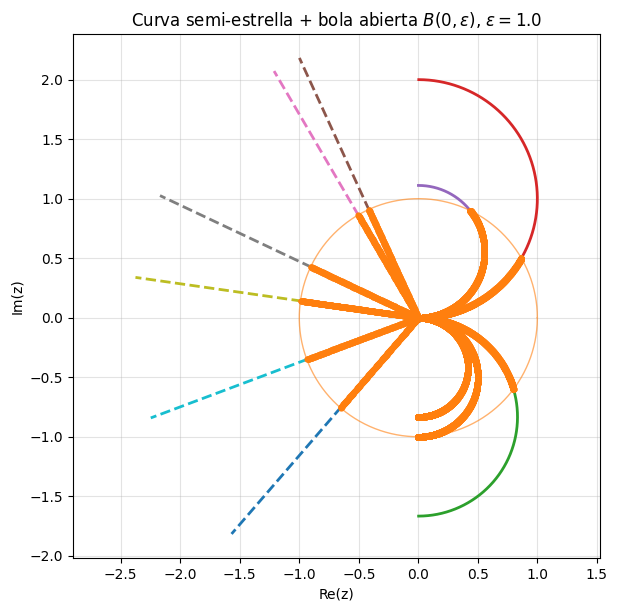

<Figure size 640x480 with 0 Axes>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_star_like_with_ball(c_list, beta_list, epsilon,
                                   n_arc=20000, n_ray=600,
                                   x_min=1e-3, x_max=1e3, r_len=None,
                                   max_labels=40):
    """
    Dibuja el modelo (1.1) y superpone la bola abierta B(0, epsilon).
    - Resalta en naranja TODOS los puntos muestreados de la curva dentro de la bola.
    - Etiqueta como Γ_i (i=1..N) hasta 'max_labels' para no saturar.
    Devuelve: (ax, z_components, z_in_ball)
    """
    fig, ax = plt.subplots(figsize=(6.8, 6.8))

    x = np.logspace(np.log10(x_min), np.log10(x_max), n_arc)
    z_components = []

    # Arcos
    for ck in c_list:
        z = 1.0 / (x - 1j*ck)
        ax.plot(z.real, z.imag, lw=2)
        z_components.append(z)

    # Rayos
    if r_len is None:
        r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))
    r = np.linspace(0.0, r_len, n_ray)
    for beta in beta_list:
        z = np.exp(1j*beta) * r
        ax.plot(z.real, z.imag, '--', lw=2)
        z_components.append(z)

    # Bola abierta (borde tenue)
    theta = np.linspace(0, 2*np.pi, 800)
    circ = epsilon * np.exp(1j*theta)
    ax.plot(circ.real, circ.imag, lw=1.0, alpha=0.6)
    ax.scatter([0],[0], c='k', s=25, zorder=5)

    # Puntos de la curva dentro de la bola (abierta)
    eps = float(epsilon)
    inside_points = []
    for z in z_components:
        mask = np.abs(z) < eps
        inside_points.append(z[mask])

    z_in_ball = (np.concatenate([zi.astype(complex) for zi in inside_points if zi.size > 0])
                 if inside_points else np.array([], dtype=complex))

    # Resaltar y etiquetar
    if z_in_ball.size > 0:
        ax.scatter(z_in_ball.real, z_in_ball.imag, s=12, zorder=10, c='tab:orange')
        N = z_in_ball.size
        idxs = np.arange(N) if N <= max_labels else np.linspace(0, N-1, max_labels, dtype=int)
        offset = 0.02*eps
        #for i, k in enumerate(idxs, start=1):
        #    ax.text(z_in_ball[k].real + offset, z_in_ball[k].imag + offset,
        #            rf'$\Gamma_{{{i}}}$', fontsize=8)

    ax.axis('equal'); ax.grid(True, alpha=0.35)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    ax.set_title(rf'Curva semi-estrella + bola abierta $B(0,\varepsilon)$, $\varepsilon={epsilon}$')
    plt.scatter([0],[0], c='k', s=25, zorder=5)
    plt.show()
    return ax, z_components, z_in_ball

# Ejemplo de uso
c_list   = [-1.2,-1.0, -0.6, 0.5, 0.9]
beta_list = [2.0,2.1, 2.7, 3.0, 3.5, 4.0]
epsilon = 1.0

ax, z_comps, z_inside = plot_model_star_like_with_ball(c_list, beta_list, epsilon)

plt.gcf().savefig("fig_modelo_con_bola.png", dpi=300, bbox_inches="tight")


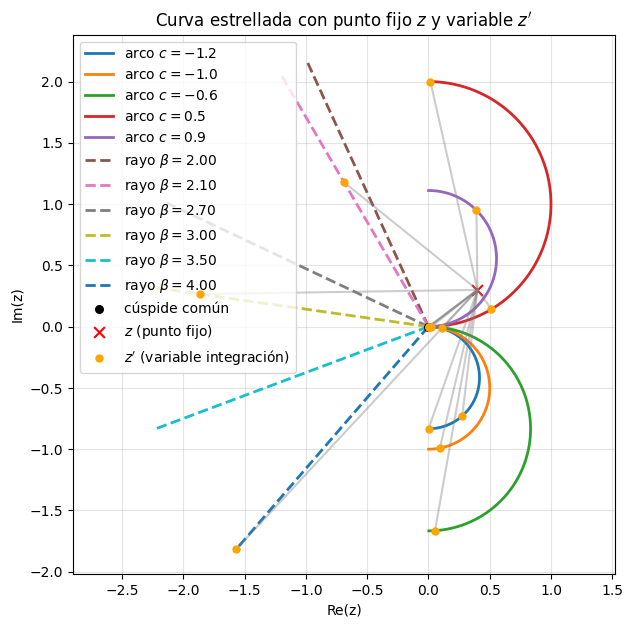

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_star_like_with_point(c_list, beta_list,
                                    z0=0.4+0.3j,
                                    n_arc=2000, n_ray=400,
                                    x_min=1e-3, x_max=1e3, r_len=None):
    """
    Dibuja la curva del modelo (1.1) y un punto fijo z0.
    Además muestra algunos puntos z' sobre la curva, conectados a z0,
    para ilustrar la integral singular de Cauchy.
    """

    plt.figure(figsize=(7,7))

    # ---- Arcos: t = 1/(x - i c_k), x ∈ R_+ ----
    x = np.logspace(np.log10(x_min), np.log10(x_max), n_arc)
    curve_points = []
    for ck in c_list:
        z = 1.0 / (x - 1j*ck)
        plt.plot(z.real, z.imag, lw=2, label=fr'arco $c={ck}$')
        curve_points.extend(z)

    # ---- Rayos: t = e^{iβ} x, x ≥ 0 ----
    if r_len is None:
        r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))
    r = np.linspace(0.0, r_len, n_ray)
    for beta in beta_list:
        z = np.exp(1j*beta) * r
        plt.plot(z.real, z.imag, '--', lw=2, label=fr'rayo $\beta={beta:.2f}$')
        curve_points.extend(z)

    # ---- Punto cúspide común (origen) ----
    plt.scatter([0],[0], c='k', s=30, zorder=5, label="cúspide común")

    # ---- Punto fijo z0 donde se evalúa el operador ----
    plt.scatter([z0.real], [z0.imag], c='red', s=60, marker='x', label='$z$ (punto fijo)')

    # ---- Algunos puntos de integración z' sobre la curva ----
    curve_points = np.array(curve_points)
    idx_samples = np.linspace(0, len(curve_points)-1, 15, dtype=int)  # 15 puntos
    z_samples = curve_points[idx_samples]

    plt.scatter(z_samples.real, z_samples.imag, c='orange', s=25, zorder=6, label='$z\'$ (variable integración)')

    # Líneas de conexión z' -> z
    for zprime in z_samples:
        plt.plot([zprime.real, z0.real], [zprime.imag, z0.imag], 'gray', alpha=0.4)

    # ---- Ajustes de gráfica ----
    plt.axis('equal'); plt.grid(True, alpha=0.35)
    plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
    plt.title(r'Curva estrellada con punto fijo $z$ y variable $z^\prime$')
    plt.legend(loc='best')
    plt.show()


# ----------------- ejemplo de uso -----------------
c_list   = [-1.2,-1.0, -0.6, 0.5, 0.9]
beta_list = [2.0, 2.1, 2.7, 3.0, 3.5, 4.0]
z0 = 0.4 + 0.3j   # punto fijo donde se evalúa el operador

plot_model_star_like_with_point(c_list, beta_list, z0=z0)


z0 = (0.4+0.3j)
(S_Γ f)(z0) ≈ (3.343957350298228-0.2652147628325986j)


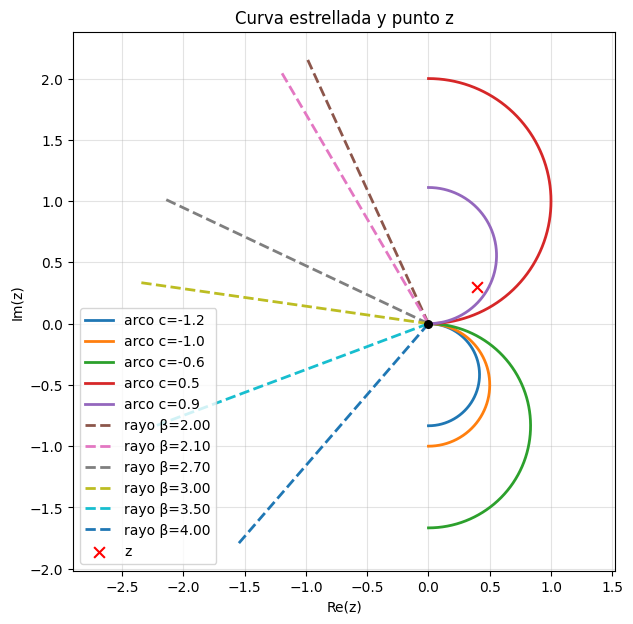

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- f de prueba ---
def f_example(t):
    # Suave y acotada en C: útil para pruebas numéricas
    return 1.0 / (1.0 + t**2)

# --- S_\Gamma f(z): Cauchy SIO sobre la curva estrellada del modelo (1.1) ---
def cauchy_S_on_star(f, c_list, beta_list, z,
                     n_arc=4000, n_ray=1500,
                     x_min=1e-4, x_max=1e4, r_len=None,
                     eps_pv=1e-6, return_diagnostics=False):
    """
    Aproxima (S_Γ f)(z) = (1/(π i)) p.v. ∫_Γ f(t)/(t - z) dt
    Γ = ⋃ arcos t(x)=1/(x - i c_k), x>0 (orientados hacia 0)
        ⋃ rayos t(r)=e^{iβ} r, r≥0      (orientados hacia 0)
    """
    # Longitud típica de rayos si no se da
    if r_len is None:
        r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))

    total = 0.0 + 0.0j
    used_pts = []

    # ---- Arcos: param x de x_max -> x_min para orientar hacia 0
    x = np.logspace(np.log10(x_max), np.log10(x_min), n_arc)
    dx = np.diff(x)
    for ck in c_list:
        t = 1.0 / (x - 1j*ck)                 # t(x)
        dt_dx = -1.0 / (x - 1j*ck)**2         # dt/dx
        integrand = f(t) / (t - z) * dt_dx    # f(t)/(t-z) * dt/dx

        # Parte principal: descartar |t-z|<eps_pv
        mask = np.abs(t - z) > eps_pv
        t = t[mask]; integrand = integrand[mask]
        # Cuadratura trapecio en x
        contrib = np.sum(0.5*(integrand[1:] + integrand[:-1]) * dx[:len(integrand)-1])
        total += contrib
        if return_diagnostics:
            used_pts.append(t)

    # ---- Rayos: param r de r_len -> 0 para orientar hacia 0
    r = np.linspace(r_len, 0.0, n_ray)
    dr = np.diff(r)
    for beta in beta_list:
        eib = np.exp(1j*beta)
        t = eib * r                            # t(r)
        dt_dr = eib * np.ones_like(r)          # dt/dr
        integrand = f(t) / (t - z) * dt_dr

        mask = np.abs(t - z) > eps_pv
        t = t[mask]; integrand = integrand[mask]
        contrib = np.sum(0.5*(integrand[1:] + integrand[:-1]) * dr[:len(integrand)-1])
        total += contrib
        if return_diagnostics:
            used_pts.append(t)

    Sfz = (1.0/(np.pi*1j)) * total
    if return_diagnostics:
        return Sfz, used_pts
    return Sfz

# ----------------- Ejemplo reproducible -----------------
if __name__ == "__main__":
    # Curva del usuario
    c_list    = [-1.2, -1.0, -0.6, 0.5, 0.9]
    beta_list = [2.0, 2.1, 2.7, 3.0, 3.5, 4.0]

    z0 = 0.4 + 0.3j   # punto donde evaluamos S_Γ f
    Sfz = cauchy_S_on_star(f_example, c_list, beta_list, z0,
                           n_arc=4000, n_ray=1500,
                           x_min=1e-4, x_max=1e4, r_len=None,
                           eps_pv=1e-6)

    print("z0 =", z0)
    print("(S_Γ f)(z0) ≈", Sfz)

    # (Opcional) visualiza la curva y el punto z0
    def plot_curve(c_list, beta_list, r_len=None):
        plt.figure(figsize=(7,7))
        x = np.logspace(-4, 4, 4000)
        for ck in c_list:
            z = 1.0/(x - 1j*ck)
            plt.plot(z.real, z.imag, lw=2, label=f"arco c={ck}")
        if r_len is None:
            r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))
        r = np.linspace(0, r_len, 600)
        for beta in beta_list:
            z = np.exp(1j*beta)*r
            plt.plot(z.real, z.imag, '--', lw=2, label=f"rayo β={beta:.2f}")
        plt.scatter([0],[0], c='k', s=30, zorder=5)
        plt.scatter([z0.real],[z0.imag], c='r', marker='x', s=60, label='z')
        plt.axis('equal'); plt.grid(True, alpha=0.35)
        plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
        plt.title('Curva estrellada y punto z')
        plt.legend(loc='best')
        plt.show()

    plot_curve(c_list, beta_list)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =======================
# Configuración del ejemplo
# =======================
# Curva estrellada del modelo (1.1)
c_list    = [-1.2, -1.0, -0.6, 0.5, 0.9]
beta_list = [2.0, 2.1, 2.7, 3.0, 3.5, 4.0]

# Función de prueba (puedes cambiarla)
def f_example(t):
    # Suave y estable para pruebas
    return 1.0 / (1.0 + t**2)

# Parámetros numéricos (puedes subirlos para más precisión)
n_arc_curve = 3000
n_ray_curve = 900
x_min, x_max = 1e-4, 1e4
r_len = None  # si None, se calcula a partir de c_list
eps_pv = 2e-5  # radio excluido para la parte principal

# Densidad para el mapa en el plano
grid_N = 120      # 100–140 va bien; subir aumenta el costo
xlim = (-1.6, 1.4)
ylim = (-1.9, 2.2)

# =======================
# Construcción de la curva (puntos + derivadas para cuadratura)
# =======================
def star_like_points_and_derivatives(c_list, beta_list,
                                     n_arc=2000, n_ray=600,
                                     x_min=1e-4, x_max=1e4, r_len=None,
                                     orient_to_zero=True):
    """
    Devuelve arrays concatenados de puntos t y derivadas dt/ds (s=parámetro),
    junto con índices que separan arcos y rayos (para colorear/diagnóstico).
    Si orient_to_zero=True, los parámetros van hacia 0 (orientación a la cúspide).
    """
    pts = []
    dps = []
    seg_bounds = []  # [(start_idx, end_idx, 'arc'/'ray', param_value_array)]
    start = 0

    # Arcos: t(x) = 1/(x - i c_k)
    if orient_to_zero:
        x = np.logspace(np.log10(x_max), np.log10(x_min), n_arc)
    else:
        x = np.logspace(np.log10(x_min), np.log10(x_max), n_arc)
    for ck in c_list:
        t = 1.0 / (x - 1j*ck)
        dt_dx = -1.0 / (x - 1j*ck)**2
        pts.append(t); dps.append(dt_dx)
        end = start + len(t)
        seg_bounds.append((start, end, 'arc', x.copy(), ck))
        start = end

    # Rayos: t(r) = e^{i beta} r
    if r_len is None:
        _r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))
    else:
        _r_len = r_len
    r = np.linspace(_r_len, 0.0, n_ray) if orient_to_zero else np.linspace(0.0, _r_len, n_ray)
    for beta in beta_list:
        eib = np.exp(1j*beta)
        t = eib * r
        dt_dr = eib * np.ones_like(r)
        pts.append(t); dps.append(dt_dr)
        end = start + len(t)
        seg_bounds.append((start, end, 'ray', r.copy(), beta))
        start = end

    pts = np.concatenate(pts) if len(pts) else np.array([], dtype=complex)
    dps = np.concatenate(dps) if len(dps) else np.array([], dtype=complex)
    return pts, dps, seg_bounds, _r_len

# =======================
# Operador de Cauchy sobre la curva (parte principal)
# =======================
def cauchy_S_on_curve_points(f, pts, dps, z, eps_pv=1e-6):
    """
    Aproxima (S_Γ f)(z) = (1/(π i)) p.v. ∫_Γ f(t)/(t-z) dt
    pts: puntos concatenados de la curva
    dps: derivada dt/ds con respecto al parámetro local
    """
    t = pts
    dt = dps
    # Máscara de parte principal
    mask = np.abs(t - z) > eps_pv
    t = t[mask]; dt = dt[mask]
    integrand = f(t) / (t - z) * dt

    # Cuadratura por tramos: suponemos malla uniforme por segmento original;
    # como están concatenados, usamos trapecio global (es razonable aquí).
    # Para integridad, hacemos trapecio simple:
    contrib = np.trapz(integrand)  # trapecio en el índice (parámetro implícito)
    return (1.0/(np.pi*1j)) * contrib

# =======================
# 1) Imagen de f sobre la curva (ANTES)
# =======================
def plot_fig1_f_on_curve(c_list, beta_list, f, save_path="fig1_f_on_curve.png"):
    pts, dps, segs, _r = star_like_points_and_derivatives(
        c_list, beta_list, n_arc_curve, n_ray_curve, x_min, x_max, r_len, orient_to_zero=False
    )
    fvals = f(pts)
    fig, ax = plt.subplots(figsize=(7,7))
    # Dibujamos por segmentos para que se vea continuo
    for (a,b,kind,param,tag) in segs:
        z = pts[a:b]
        ax.plot(z.real, z.imag, color='lightgray', lw=2, zorder=1)
        # sobrepone color por |f|
        sc = ax.scatter(z.real, z.imag, c=np.abs(f(z)), s=4, cmap='viridis', zorder=2)
    plt.colorbar(sc, ax=ax, label=r'$|f(t)|$')
    ax.scatter([0],[0], c='k', s=25, zorder=3)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_title('ANTES: $f$ sobre la curva $\\Gamma$ (color = $|f|$)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.close(fig)
    return pts, dps

# =======================
# 2) (SΓ f)(z) evaluado en la propia curva (parte principal)
# =======================
def plot_fig2_Sf_on_curve(c_list, beta_list, f, pts, dps, save_path="fig2_Sf_on_curve.png"):
    # Tomamos un subconjunto para no hacer demasiado costoso
    idx = np.linspace(0, len(pts)-1, 120, dtype=int)
    z_eval = pts[idx]

    Sf_vals = np.array([cauchy_S_on_curve_points(f, pts, dps, z, eps_pv=eps_pv) for z in z_eval])

    fig, ax = plt.subplots(figsize=(7,7))
    # Curva base
    ax.plot(pts.real, pts.imag, color='lightgray', lw=2)
    # Color por |SΓ f|
    sc = ax.scatter(z_eval.real, z_eval.imag, c=np.abs(Sf_vals), s=18, cmap='magma')
    plt.colorbar(sc, ax=ax, label=r'$|(S_\Gamma f)(z)|$ (en $z\in\Gamma$)')
    ax.scatter([0],[0], c='k', s=25)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_title('EN LA CURVA: $(S_\\Gamma f)(z)$ (parte principal)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.close(fig)

# =======================
# 3) Mapa en el plano de (SΓ f)(z) (DESPUÉS)
# =======================
def plot_fig3_Sf_on_plane(c_list, beta_list, f, save_path="fig3_Sf_on_plane.png"):
    # Curva con orientación hacia 0 para cuadratura más estable
    pts, dps, segs, _r = star_like_points_and_derivatives(
        c_list, beta_list, n_arc_curve, n_ray_curve, x_min, x_max, r_len, orient_to_zero=True
    )

    xs = np.linspace(xlim[0], xlim[1], grid_N)
    ys = np.linspace(ylim[0], ylim[1], grid_N)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = XX + 1j*YY

    Sf_grid = np.zeros_like(ZZ, dtype=complex)

    # Evaluación en la malla (esto puede tardar si grid_N es grande)
    for i in range(grid_N):
        for j in range(grid_N):
            z = ZZ[i, j]
            Sf_grid[i, j] = cauchy_S_on_curve_points(f, pts, dps, z, eps_pv=eps_pv)

    fig, ax = plt.subplots(figsize=(7.2,7.2))
    im = ax.imshow(np.abs(Sf_grid), extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
                   origin='lower', interpolation='bilinear')
    plt.colorbar(im, ax=ax, label=r'$|(S_\Gamma f)(z)|$')
    # Superponemos la curva
    ax.plot(pts.real, pts.imag, color='white', lw=1.2, alpha=0.95)
    ax.scatter([0],[0], c='w', s=18, zorder=3)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_title('DESPUÉS: mapa de $|(S_\\Gamma f)(z)|$ en el plano')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.close(fig)

# =======================
# Ejecutar todo
# =======================
if __name__ == "__main__":
    # 1) f sobre la curva (ANTES)
    pts_curve, dps_curve = plot_fig1_f_on_curve(c_list, beta_list, f_example)

    # 2) (SΓ f)(z) en z sobre la curva (parte principal)
    plot_fig2_Sf_on_curve(c_list, beta_list, f_example, pts_curve, dps_curve)

    # 3) Mapa en el plano (DESPUÉS)
    plot_fig3_Sf_on_plane(c_list, beta_list, f_example)

    print("Listo. Se guardaron:")
    print(" - fig1_f_on_curve.png")
    print(" - fig2_Sf_on_curve.png")
    print(" - fig3_Sf_on_plane.png")


AttributeError: module 'numpy' has no attribute 'trapz'

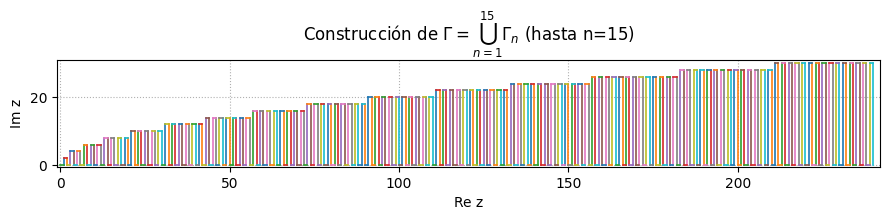

In [6]:
import matplotlib.pyplot as plt

def gamma_segments_for_n(n: int):
    """
    Construye los segmentos de Γ_n.
    Definición:
      x_{n,k} = n^2 - n + k         (k = 0,1,...,2n)
      y_{n,k} = x_{n,k} + 2 n i
    Γ_n es la unión de:
      - verticales [x_{n,k}, y_{n,k}] para k=1..2n
      - horizontales inferiores [x_{n,k}, x_{n,k+1}] para k par (0..2n-2)
      - horizontales superiores [y_{n,k}, y_{n,k+1}] para k impar (1..2n-1)
    """
    segs = []
    xs = [n**2 - n + k for k in range(2*n + 1)]

    # Verticales
    for k in range(1, 2*n + 1):
        x = xs[k]
        segs.append(((x, 0.0), (x, 2.0*n)))

    # Horizontales abajo (k par)
    for k in range(0, 2*n, 2):
        segs.append(((xs[k], 0.0), (xs[k+1], 0.0)))

    # Horizontales arriba (k impar)
    for k in range(1, 2*n, 2):
        segs.append(((xs[k], 2.0*n), (xs[k+1], 2.0*n)))

    return segs

def gamma_segments(N_max: int):
    segs = []
    for n in range(1, N_max + 1):
        segs.extend(gamma_segments_for_n(n))
    return segs

def plot_gamma(N_max: int = 6, savepath: str | None = "gamma_curve.png"):
    segs = gamma_segments(N_max)
    fig, ax = plt.subplots(figsize=(9, 4))
    for (x0, y0), (x1, y1) in segs:
        ax.plot([x0, x1], [y0, y1], lw=1.2)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Re z")
    ax.set_ylabel("Im z")
    ax.set_title(rf"Construcción de $\Gamma = \bigcup_{{n=1}}^{{ 15 }} \Gamma_n$ (hasta n={N_max})")

    # Límites del gráfico
    xmin = 0
    xmax = (N_max**2 + N_max) + 1
    ymax = 2*N_max + 1
    ax.set_xlim(xmin - 1, xmax + 1)
    ax.set_ylim(-0.5, ymax)
    ax.grid(True, linestyle=":")
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=200)
    plt.show()

if __name__ == "__main__":
    plot_gamma(N_max=15, savepath="gamma_curve.png")


In [7]:
int("5")

5

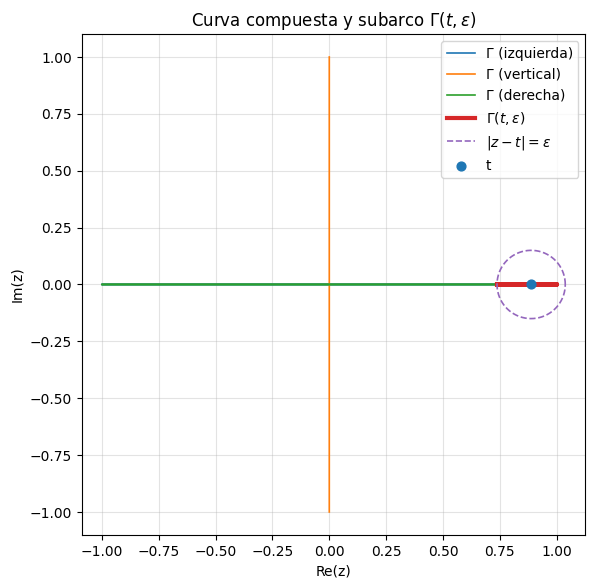

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =================== Parámetros ===================
N1, N2, N3 = 4000, 4000, 1200     # resolución por rama
x_gap = 1e-3                       # evita x=0
branch = 'right'                   # 'left' | 'vertical' | 'right'
x0 = 0.12                          # si branch='left' o 'right'
y0 = 0.40                          # si branch='vertical'
eps = 0.15                         # radio ε
# ==================================================

# --- Ramas de Γ ---
x_left  = np.linspace(-1, -x_gap, N1)
z_left  = np.sin(1/np.abs(x_left)) + 0j

y_vert  = np.linspace(-1, 1, N3)
z_vert  = 1j*y_vert

x_right = np.linspace(x_gap, 1, N2)
z_right = np.sin(1/x_right) + 0j

def join_with_nans(segments):
    out = []
    for s in segments:
        out.append(s)
        out.append(np.array([np.nan + 1j*np.nan]))
    return np.concatenate(out)

# Para la máscara trabajamos con todas las muestras (con NaNs que cortan líneas)
z_all = join_with_nans([z_left, z_vert, z_right])

# --- Elige t de forma segura según la rama ---
def pick_t(branch, x0, y0):
    if branch == 'left':
        # x en [-1, -x_gap]
        x = float(x0)
        x = np.clip(x, -1, -x_gap)
        return np.sin(1/abs(x)) + 0j
    elif branch == 'right':
        # x en [x_gap, 1]
        x = float(x0)
        x = np.clip(x, x_gap, 1.0)
        return np.sin(1/x) + 0j
    elif branch == 'vertical':
        y = float(np.clip(y0, -1, 1))
        return 1j*y
    else:
        raise ValueError("branch debe ser 'left', 'vertical' o 'right'")

t = pick_t(branch, x0, y0)

# --- Subarco Γ(t, ε) ---
mask = np.abs(z_all - t) < eps
xh = np.where(mask, z_all.real, np.nan)
yh = np.where(mask, z_all.imag, np.nan)

# Circunferencia |z - t| = ε
phi = np.linspace(0, 2*np.pi, 600)
circle = t + eps * (np.cos(phi) + 1j*np.sin(phi))

# ----------------- Gráfica -----------------
plt.figure(figsize=(6.5, 6.5))
# Dibuja cada rama por separado (sin unir con segmentos rectos)
plt.plot(z_left.real,  z_left.imag,  lw=1.2, label='Γ (izquierda)')
plt.plot(z_vert.real,  z_vert.imag,  lw=1.2, label='Γ (vertical)')
plt.plot(z_right.real, z_right.imag, lw=1.2, label='Γ (derecha)')

# Resalta Γ(t, ε)
plt.plot(xh, yh, lw=3, label=r'$\Gamma(t,\varepsilon)$')

# Disco ε y punto t
plt.plot(circle.real, circle.imag, '--', lw=1.2, label=r'$|z-t|=\varepsilon$')
plt.scatter([t.real], [t.imag], s=40, zorder=3, label='t')

plt.axis('equal'); plt.grid(True, alpha=0.35)
plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
plt.title('Curva compuesta y subarco $\\Gamma(t,\\varepsilon)$')
plt.legend()
plt.show()


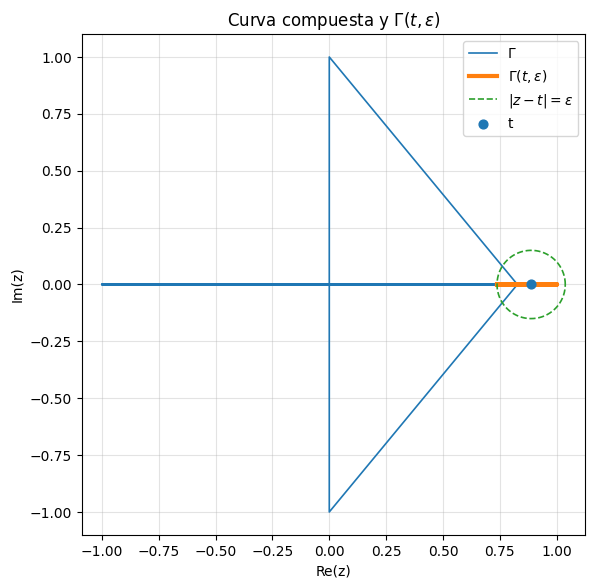

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------- Parámetros de muestreo -------------------
N1, N2, N3 = 4000, 4000, 1200   # puntos por rama
x_gap = 1e-3                     # evita x=0
# ------------------- Punto t y radio ε ------------------------
branch = 'right'   # 'left' | 'vertical' | 'right'
x0 = 0.12          # si branch='left' o 'right' (elige en su dominio)
y0 = 0.4           # si branch='vertical'
eps = 0.15         # ε
# --------------------------------------------------------------

# Ramas de Γ
x_left  = np.linspace(-1, -x_gap, N1)
z_left  = np.sin(1/np.abs(x_left)) + 0j

y_vert  = np.linspace(-1, 1, N3)
z_vert  = 1j*y_vert

x_right = np.linspace(x_gap, 1, N2)
z_right = np.sin(1/x_right) + 0j

# Curva completa concatenada (como polilínea)
z = np.concatenate([z_left, z_vert, z_right])

# Elige el punto t en la rama indicada
if branch == 'left':
    assert -1 <= x0 < 0, "x0 debe estar en [-1, 0)"
    t = np.sin(1/np.abs(x0)) + 0j
elif branch == 'right':
    assert 0 < x0 <= 1, "x0 debe estar en (0, 1]"
    t = np.sin(1/x0) + 0j
elif branch == 'vertical':
    assert -1 <= y0 <= 1, "y0 debe estar en [-1, 1]"
    t = 1j*y0
else:
    raise ValueError("branch debe ser 'left', 'vertical' o 'right'")

# Subarco Γ(t, ε)
mask = np.abs(z - t) < eps
xh = np.where(mask, z.real, np.nan)
yh = np.where(mask, z.imag, np.nan)

# Circunferencia |z - t| = ε
phi = np.linspace(0, 2*np.pi, 600)
circle = t + eps * (np.cos(phi) + 1j*np.sin(phi))

# ------------------- Gráfica -------------------
plt.figure(figsize=(6.5, 6.5))
plt.plot(z.real, z.imag, lw=1.2, label='Γ')                      # curva completa
plt.plot(xh, yh, lw=3, label=r'$\Gamma(t,\varepsilon)$')         # subarco resaltado
plt.plot(circle.real, circle.imag, '--', lw=1.2, label=r'$|z-t|=\varepsilon$')
plt.scatter([t.real], [t.imag], s=40, zorder=3, label='t')

plt.axis('equal'); plt.grid(True, alpha=0.35)
plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
plt.title(r'Curva compuesta y $\Gamma(t,\varepsilon)$')
plt.legend()
plt.show()


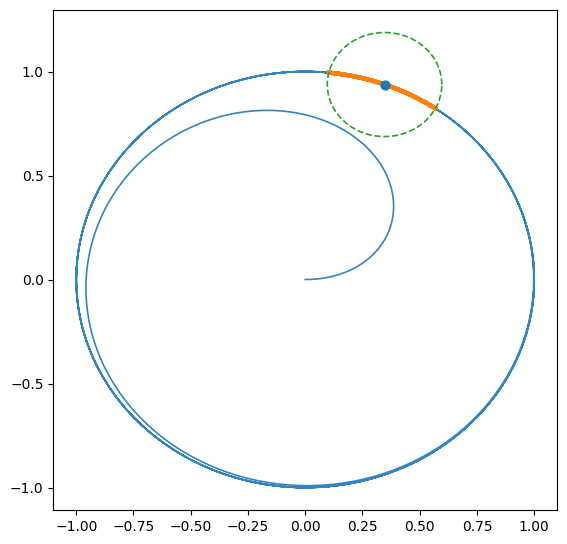

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== Parámetros ====================
theta_max = 12*np.pi   # cuántas vueltas de la curva
n_samples = 5000       # resolución de la muestra
theta0     = 7.5       # elige el punto t mediante θ0 (en radianes)
eps        = 0.25      # radio ε del disco
# ====================================================

def gamma_theta(th):
    """Curva Γ parametrizada: z(θ) = (1 - e^{-θ}) e^{iθ}."""
    return (1 - np.exp(-th)) * np.exp(1j * th)

# Curva completa
theta = np.linspace(0, theta_max, n_samples)
z = gamma_theta(theta)

# Punto t en la curva y disco ε
t = gamma_theta(theta0)

# Subconjunto Γ(t, ε) = {τ ∈ Γ : |τ - t| < ε}
mask = np.abs(z - t) < eps

# Usamos NaN para romper líneas fuera del disco
xh = np.where(mask, z.real, np.nan)
yh = np.where(mask, z.imag, np.nan)

# Circunferencia |z - t| = ε
phi = np.linspace(0, 2*np.pi, 720)
circle = t + eps * (np.cos(phi) + 1j*np.sin(phi))

# ----- Gráfica -----
plt.figure(figsize=(6.5, 6.5))
plt.plot(z.real, z.imag, lw=1.2, alpha=0.9, label='Γ')
plt.plot(xh, yh, lw=3, label=r'$\Gamma(t,\varepsilon)$')
plt.plot(circle.real, circle.imag, '--', lw=1.2, label=r'$|z-t|=\varepsilon$')
plt.scatter([t.real], [t.imag], s=40, zorder=3, label='t')

#plt.axis('equal'); plt.grid(True, alpha=0.35)
#plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
#plt.title(r'$\Gamma(t,\varepsilon)$ en $\Gamma=\{(1-e^{-\theta})e^{i\theta}:\ \theta\geq 0\}$'
#          f'\n$t=z({theta0:.2f})$, $\\varepsilon={eps}$')
#plt.legend()
plt.show()


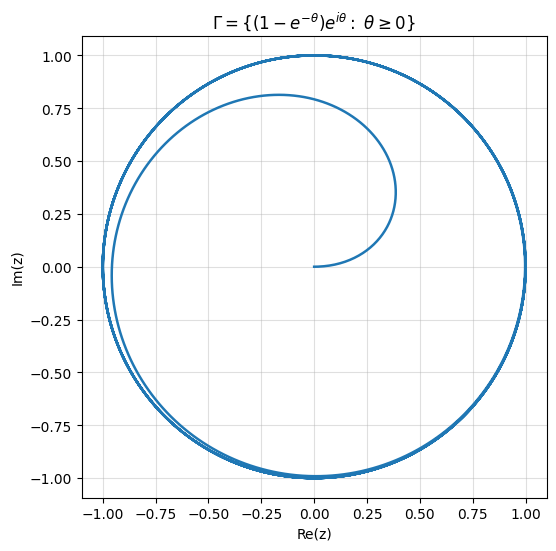

In [11]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 12*np.pi, 4000)
z = (1 - np.exp(-theta)) * np.exp(1j * theta)   # Γ(θ)

plt.figure(figsize=(6,6))
plt.plot(z.real, z.imag, lw=1.8)
plt.axis('equal'); plt.grid(True, alpha=0.4)
plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
plt.title(r'$\Gamma=\{(1-e^{-\theta})e^{i\theta}:\ \theta\geq 0\}$')  # <- \geq
plt.show()


In [12]:
!python pip install

python: can't open file '/home/enriquedo/PersonalProjects/manim-figures-bk/notebooks/math/pip': [Errno 2] No such file or directory


In [13]:
len("_Hola_")

6

In [14]:
type(len("_Hola_"))

int

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración común
def configurar_grafico(title=None):
    plt.figure(figsize=(6,6), dpi=300)
    plt.axis("equal")
    plt.axis("off")
    if title:
        plt.title(title, fontsize=14)

# 1. Circunferencia unitaria
def figura_circunferencia(nombre="circunferencia.png"):
    theta = np.linspace(0, 2*np.pi, 400)
    x, y = np.cos(theta), np.sin(theta)
    configurar_grafico("Circunferencia Unitaria")
    plt.plot(x, y, "b")
    plt.savefig(nombre, bbox_inches="tight")
    plt.close()

# 2. Estrella (star-like simple)
def figura_star(nombre="star.png"):
    theta = np.linspace(0, 2*np.pi, 400)
    r = 1 + 0.3*np.cos(5*theta)   # radial perturbation
    x, y = r*np.cos(theta), r*np.sin(theta)
    configurar_grafico("Curva tipo Star-like")
    plt.plot(x, y, "r")
    plt.savefig(nombre, bbox_inches="tight")
    plt.close()

# 3. Curva con cúspide
def figura_cuspide(nombre="cuspide.png"):
    t = np.linspace(-1,1,400)
    x = t**2
    y = t**3
    configurar_grafico("Curva con Cúspide")
    plt.plot(x, y, "g")
    plt.savefig(nombre, bbox_inches="tight")
    plt.close()

# 4. Espiral de Carleson (ejemplo decorativo)
def figura_espiral(nombre="espiral.png"):
    theta = np.linspace(0,4*np.pi,600)
    r = 1/(1+theta) + 0.1
    x, y = r*np.cos(theta), r*np.sin(theta)
    configurar_grafico("Espiral tipo Carleson")
    plt.plot(x,y,"m")
    plt.savefig(nombre, bbox_inches="tight")
    plt.close()

# 5. Imagen marco para número de diapositiva
def figura_marco(color="c", nombre="marco.png"):
    theta = np.linspace(0, 2*np.pi, 400)
    r = 1.2 + 0.2*np.sin(6*theta)
    x, y = r*np.cos(theta), r*np.sin(theta)
    configurar_grafico("Marco para número")
    plt.plot(x, y, color)
    # en el centro irá el número (lo añadirás en PowerPoint/Keynote)
    plt.savefig(nombre, bbox_inches="tight")
    plt.close()

# Generar todas
figura_circunferencia()
figura_star()
figura_cuspide()
figura_espiral()
figura_marco()


Imagen guardada en: carleson_local_intuicion.png


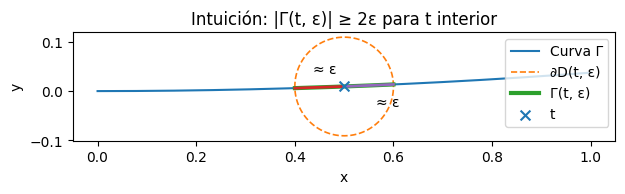

In [16]:
# Intuición visual de la cota inferior local: |Γ(t, ε)| ≥ 2ε (t interior)
# Requiere: numpy, matplotlib

import numpy as np
import matplotlib.pyplot as plt

# ---- Curva de ejemplo (modifícala si quieres) ----
def f(x):
    return 0.3 * np.sin(1.0/8.0 * x)*x

# Punto interior t y radio ε
x0 = 0.5
y0 = f(x0)
eps = 0.10  # radio del disco

# ---- Malla y utilidades ----
xs = np.linspace(0, 1, 4000)
ys = f(xs)

# Distancia al centro del disco
dist = np.sqrt((xs - x0) ** 2 + (ys - y0) ** 2)
g = dist - eps  # cambia de signo cuando la curva corta la circunferencia

# Índices donde hay cambio de signo (aprox. intersecciones)
signs = np.sign(g)
cross_idx = np.where(signs[:-1] * signs[1:] <= 0)[0]

def bisect_root(a, b, fa, fb, func, it=40):
    """Bisección robusta para localizar la raíz en [a,b] con fa*fb <= 0."""
    left, right = a, b
    fleft, fright = fa, fb
    for _ in range(it):
        mid = 0.5 * (left + right)
        fmid = func(mid)
        if fleft * fmid <= 0:
            right, fright = mid, fmid
        else:
            left, fleft = mid, fmid
    return 0.5 * (left + right)

# Refinar intersecciones cerca de x0 y quedarnos con las 2 más cercanas
roots = []
for i in cross_idx:
    a, b = xs[i], xs[i+1]
    fa, fb = g[i], g[i+1]
    if abs(a - x0) < 0.3 and abs(b - x0) < 0.3:
        r = bisect_root(a, b, fa, fb,
                        lambda x: np.sqrt((x - x0) ** 2 + (f(x) - y0) ** 2) - eps)
        roots.append(r)
roots = sorted(roots, key=lambda r: abs(r - x0))[:2]
roots = sorted(roots)  # izquierda, derecha

# Sub-arco dentro del disco: componente conexo que contiene a x0
inside = dist <= eps
idx0 = np.argmin(np.abs(xs - x0))
L = R = idx0
while L - 1 >= 0 and inside[L - 1]:
    L -= 1
while R + 1 < len(xs) and inside[R + 1]:
    R += 1

# ---- Figura ----
fig, ax = plt.subplots(figsize=(7, 6))

# Curva completa Γ
ax.plot(xs, ys, linewidth=1.5, label="Curva Γ")

# Circunferencia ∂D(t, ε)
theta = np.linspace(0, 2 * np.pi, 600)
ax.plot(x0 + eps * np.cos(theta), y0 + eps * np.sin(theta),
        linestyle="--", linewidth=1.2, label="∂D(t, ε)")

# Sub-arco Γ(t, ε)
ax.plot(xs[L:R+1], ys[L:R+1], linewidth=3.0, label="Γ(t, ε)")

# Punto t
ax.scatter([x0], [y0], s=50, zorder=5, label="t", marker="x")

# “Dos radios” (si se detectaron dos intersecciones)
if len(roots) == 2:
    xL, xR = roots
    yL, yR = f(xL), f(xR)
    ax.plot([x0, xL], [y0, yL], linewidth=2.0)  # primer radio
    ax.plot([x0, xR], [y0, yR], linewidth=2.0)  # segundo radio
    ax.annotate("≈ ε", xy=((x0 + xL)/2, (y0 + yL)/2), xytext=(-5, 10),
                textcoords="offset points")
    ax.annotate("≈ ε", xy=((x0 + xR)/2, (y0 + yR)/2), xytext=(5, -15),
                textcoords="offset points")

ax.set_title("Intuición: |Γ(t, ε)| ≥ 2ε para t interior")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right")

# Guarda y muestra
out_path = "carleson_local_intuicion.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Imagen guardada en: {out_path}")
plt.show()


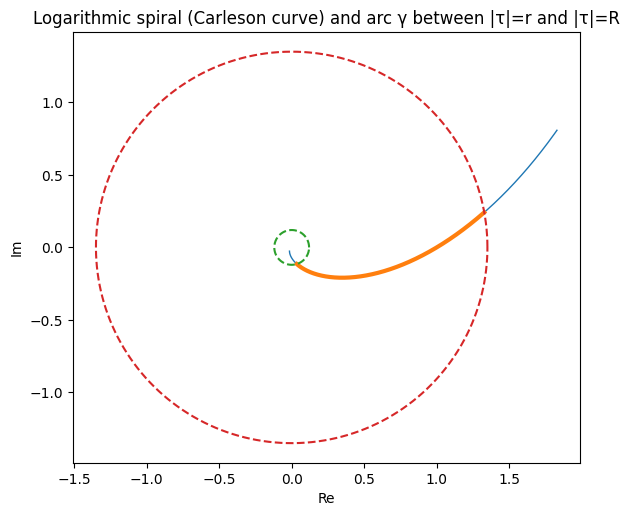

Estimated Carleson constant  C_Γ ≈ 2.067
Chosen radii: r = 0.120, R = 1.350  (R/r = 11.25)
Increment of argument Δ_γ(t) ≈ 1.4522 rad
Theorem 1.8 bound: 2π C_Γ (R/r) ≈ 146.1386 rad
Inequality satisfied? -> True


In [17]:
# Demonstration of Theorem 1.8 (Growth of the argument) on a Carleson curve.
# We use a logarithmic spiral τ = r * exp(i(θ0 + a log r)), which is a Carleson curve
# when |r φ'(r)| = |a| ≤ M (Prop. 1.4-type assumption). We then:
# 1) Numerically estimate the Carleson constant C_Γ ≈ sup_{t,ε} |Γ∩B(t,ε)| / ε.
# 2) Pick an arc γ whose endpoints lie on the circles |τ-t|=R and |τ-t|=r about t=0.
# 3) Compute Δ_γ(t) (increment of arg(τ - t)) and compare against the bound 2π C_Γ (R/r).
#
# This code produces:
# - A plot of the spiral with the selected arc and the two circles.
# - A text printout verifying the inequality Δ ≤ 2π C_Γ (R/r).

import numpy as np
import matplotlib.pyplot as plt

# ---- 1) Define the Carleson curve (logarithmic spiral) ----
a = 0.6         # controls how fast the spiral rotates; |a| = |r φ'(r)|
theta0 = 0.0
r_min, r_max = 0.03, 2.0

# parametrize by radius r (monotone) for convenience
N = 8000
r_vals = np.geomspace(r_min, r_max, N)
theta_vals = theta0 + a * np.log(r_vals)
z = r_vals * np.exp(1j * theta_vals)  # spiral points (t = 0)

# cumulative arclength along the curve for later length computations
dz = np.diff(z)
seglen = np.abs(dz)
s = np.concatenate([[0.0], np.cumsum(seglen)])

# ---- 2) Estimate the Carleson constant numerically ----
def estimate_carleson_constant(z, s, epsilons, centers_idx):
    Cvals = []
    for idx in centers_idx:
        t = z[idx]
        for eps in epsilons:
            mask = np.abs(z - t) < eps
            if not np.any(mask):
                continue
            # length of Γ∩B(t,eps): sum lengths of edges fully inside plus partials at boundary
            # We'll approximate by summing seglen over indices where BOTH endpoints lie in the ball.
            inside_edges = mask[:-1] & mask[1:]
            length_in_ball = seglen[inside_edges].sum()
            Cvals.append(length_in_ball / eps if eps > 0 else 0.0)
    return max(Cvals) if Cvals else 0.0

# choose a modest set of centers and radii
rng = np.random.default_rng(0)
centers_idx = rng.choice(np.arange(200, N-200), size=80, replace=False)
epsilons = np.geomspace(0.02, 0.4, 12)

C_est = estimate_carleson_constant(z, s, epsilons, centers_idx)

# ---- 3) Choose an arc γ with endpoints on |τ| = r and |τ| = R ----
t = 0.0 + 0.0j  # center point for argument increment
r_small, R_big = 0.12, 1.35

# find first index near r_small and first index near R_big
i_r = np.argmin(np.abs(np.abs(z - t) - r_small))
i_R = np.argmin(np.abs(np.abs(z - t) - R_big))
if i_r > i_R:
    i_r, i_R = i_R, i_r  # ensure the arc goes outward

arc_idx = np.arange(i_r, i_R + 1)
gamma = z[arc_idx]

# Δ_γ(t): unwrap the argument along the arc
angles = np.unwrap(np.angle(gamma - t))
Delta = float(np.abs(angles[-1] - angles[0]))

# Bound from Theorem 1.8
bound = 2 * np.pi * C_est * (R_big / r_small)

# ---- 4) Plot the spiral and the selected arc ----
fig1 = plt.figure(figsize=(6, 6))
plt.plot(z.real, z.imag, lw=1.0)
plt.plot(gamma.real, gamma.imag, lw=3.0)  # highlight the arc
# draw the two circles |τ| = r and |τ| = R
phi = np.linspace(0, 2*np.pi, 600)
plt.plot(r_small*np.cos(phi), r_small*np.sin(phi), ls='--')
plt.plot(R_big*np.cos(phi), R_big*np.sin(phi), ls='--')
plt.gca().set_aspect('equal', 'box')
plt.title('Logarithmic spiral (Carleson curve) and arc γ between |τ|=r and |τ|=R')
plt.xlabel('Re')
plt.ylabel('Im')
plt.tight_layout()
plt.show()

# ---- 5) Print verification ----
print("Estimated Carleson constant  C_Γ ≈ {:.3f}".format(C_est))
print("Chosen radii: r = {:.3f}, R = {:.3f}  (R/r = {:.2f})".format(r_small, R_big, R_big/r_small))
print("Increment of argument Δ_γ(t) ≈ {:.4f} rad".format(Delta))
print("Theorem 1.8 bound: 2π C_Γ (R/r) ≈ {:.4f} rad".format(bound))
print("Inequality satisfied? ->", Delta < bound)


In [18]:
# anima_curva_semi_estrella.py
# Requisitos: numpy, matplotlib, Pillow (para GIF). Opcional: ffmpeg para MP4.
# Ejecuta: python anima_curva_semi_estrella.py

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    from matplotlib.animation import FFMpegWriter
    HAVE_FFMPEG = True
except Exception:
    HAVE_FFMPEG = False

def star_like_samples(c_list, beta_list,
                      n_arc=1500, n_ray=250,
                      x_min=1e-3, x_max=1e3, r_len=None):
    """
    Devuelve listas de arrays complejos: 'arcs' y 'rays' con las muestras.
      - Arcos: t = 1/(x - i c_k), x>0
      - Rayos: t = e^{iβ} r, r≥0
    """
    # Arcos
    x = np.logspace(np.log10(x_min), np.log10(x_max), n_arc)
    arcs = [1.0 / (x - 1j*ck) for ck in c_list]

    # Longitud típica para rayos
    if r_len is None:
        r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))

    # Rayos
    r = np.linspace(0.0, r_len, n_ray)
    rays = [np.exp(1j*beta) * r for beta in beta_list]
    return arcs, rays

def animate_star_like(c_list, beta_list,
                      n_arc=1500, n_ray=250,
                      frames=90, interval_ms=40,
                      x_min=1e-3, x_max=1e3, r_len=None,
                      title=r'Curva semi estrella (animación)',
                      out_gif='curva_semi_estrella.gif',
                      out_mp4='curva_semi_estrella.mp4',
                      dpi=120):
    """
    Genera una animación donde arcos y rayos se trazan progresivamente.
    Guarda GIF; si tienes ffmpeg disponible, también MP4.
    """
    arcs, rays = star_like_samples(c_list, beta_list, n_arc, n_ray, x_min, x_max, r_len)

    # Límites de ejes
    all_x = np.concatenate([z.real for z in arcs + rays]) if (arcs or rays) else np.array([0.0])
    all_y = np.concatenate([z.imag for z in arcs + rays]) if (arcs or rays) else np.array([0.0])
    pad = 0.06
    xmin, xmax = all_x.min(), all_x.max()
    ymin, ymax = all_y.min(), all_y.max()
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= pad*dx; xmax += pad*dx
    ymin -= pad*dy; ymax += pad*dy

    # Figura
    fig, ax = plt.subplots(figsize=(6.6, 6.6))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.35)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    ax.set_title(title)
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

    # Artistas
    arc_lines = [ax.plot([], [], lw=2, label=fr'arco $c={ck}$')[0] for ck in c_list]
    ray_lines = [ax.plot([], [], ls='--', lw=2, label=fr'rayo $\beta={beta:.2f}$')[0] for beta in beta_list]
    cusp = ax.scatter([0], [0], s=25, c='k', zorder=5)

    # Easing suave (smoothstep)
    def smoothstep(t):
        return t*t*(3 - 2*t)

    def init():
        for ln in arc_lines + ray_lines:
            ln.set_data([], [])
        return arc_lines + ray_lines + [cusp]

    def update(k):
        f = smoothstep(k/(frames-1))
        # Arcos
        for idx, z in enumerate(arcs):
            n = max(2, int(f * len(z)))
            arc_lines[idx].set_data(z[:n].real, z[:n].imag)
        # Rayos
        for idx, z in enumerate(rays):
            m = max(2, int(f * len(z)))
            ray_lines[idx].set_data(z[:m].real, z[:m].imag)
        return arc_lines + ray_lines + [cusp]

    anim = FuncAnimation(fig, update, init_func=init,
                         frames=frames, interval=interval_ms, blit=True)

    # GIF (Pillow)
    gif_writer = PillowWriter(fps=max(1, int(1000/interval_ms)))
    anim.save(out_gif, writer=gif_writer, dpi=dpi)
    print(f"✔ GIF guardado en: {out_gif}")

    # MP4 (opcional si hay ffmpeg)
    if HAVE_FFMPEG:
        try:
            mp4_writer = FFMpegWriter(fps=max(1, int(1000/interval_ms)), bitrate=1800)
            anim.save(out_mp4, writer=mp4_writer, dpi=dpi)
            print(f"✔ MP4 guardado en: {out_mp4}")
        except Exception as e:
            print(f"⚠ No se pudo exportar MP4: {e}")

    plt.close(fig)

if __name__ == "__main__":
    # --- Parámetros de tu ejemplo ---
    c_list   = [-1.2, -1.0, -0.6, 0.5, 0.9]         # c_k ≠ 0
    beta_list = [2.0, 2.1, 2.7, 3.0, 3.5, 4.0]       # π/2 < β < 3π/2

    # Ajusta si quieres más/menos detalle o duración
    animate_star_like(
        c_list, beta_list,
        n_arc=1500,        # más puntos en arcos = más suave (y más pesado)
        n_ray=250,         # más puntos en rayos
        frames=100,        # más frames = animación más larga/suave
        interval_ms=35,    # ms entre frames (afecta fps del GIF/MP4)
        x_min=1e-3, x_max=1e3,
        r_len=None,        # o fija un float, p.ej. r_len=2.0
        out_gif="curva_semi_estrella.gif",
        out_mp4="curva_semi_estrella.mp4",
        dpi=130
    )


✔ GIF guardado en: curva_semi_estrella.gif
✔ MP4 guardado en: curva_semi_estrella.mp4


In [19]:
# anima_gamma_bola_variable.py
# Requisitos: numpy, matplotlib, Pillow (para GIF). Opcional: ffmpeg para MP4.
# Ejecuta: python anima_gamma_bola_variable.py

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    from matplotlib.animation import FFMpegWriter
    HAVE_FFMPEG = True
except Exception:
    HAVE_FFMPEG = False

# ==================== Parámetros ====================
theta_max   = 12*np.pi    # cuántas vueltas de la curva
n_samples   = 4000        # resolución de la muestra de la curva (más = más suave)
fps         = 12          # cuadros por segundo (para GIF/MP4)
dur_seconds = 20          # duración total aproximada de la animación
trail_len   = 0.08        # proporción [0,1] de "estela" atrás del punto (0 para sin estela)
# Radio variable: eps(t) = eps_base * (1 + eps_amp * sin(2π*freq*t_norm))
eps_base    = 0.25
eps_amp     = 0.6         # 0=no varía; 0.6 => entre 0.25*(1-0.6) y 0.25*(1+0.6)
eps_freq    = 1.0         # oscilaciones por pasada
# ====================================================

def gamma_theta(th):
    """Curva Γ parametrizada: z(θ) = (1 - e^{-θ}) e^{iθ} (θ >= 0)."""
    return (1 - np.exp(-th)) * np.exp(1j * th)

def make_animation(
    theta_max=theta_max,
    n_samples=n_samples,
    fps=fps,
    dur_seconds=dur_seconds,
    trail_len=trail_len,
    eps_base=eps_base,
    eps_amp=eps_amp,
    eps_freq=eps_freq,
    out_gif="gamma_bola_variable.gif",
    out_mp4="gamma_bola_variable.mp4",
    dpi=130
):
    # --- Muestreo fijo de la curva ---
    theta = np.linspace(0, theta_max, n_samples)
    z = gamma_theta(theta)
    x, y = z.real, z.imag

    # --- Cronograma de frames ---
    n_frames = int(fps * dur_seconds)
    # Recorremos índice a lo largo de la curva (ida "lineal" en theta)
    idxs = np.linspace(0, n_samples - 1, n_frames).astype(int)

    # --- Prepara figura ---
    fig, ax = plt.subplots(figsize=(6.6, 6.6))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.35)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    ax.set_title(r'$\Gamma(t,\varepsilon(t))$')

    # Límites con pequeño margen
    pad = 0.06
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    dx, dy = xmax - xmin, ymax - ymin
    ax.set_xlim(xmin - pad*dx, xmax + pad*dx)
    ax.set_ylim(ymin - pad*dy, ymax + pad*dy)

    # --- Artistas: curva base, resaltado, punto y círculo ---
    base_line, = ax.plot(x, y, lw=1.2, alpha=0.9, color='#444', label='Γ')
    highlight_line, = ax.plot([], [], lw=3, color='orange', label=r'$\{\tau\in\Gamma:|\tau-t|<\varepsilon\}$')
    point_scatter = ax.scatter([], [], s=40, zorder=3, color='C0', label='t')
    circle_line,  = ax.plot([], [], '--', lw=1.4, color='C1', label=r'$|z-t|=\varepsilon(t)$')

    # (Opcional) estela del punto
    if trail_len > 0:
        trail_line, = ax.plot([], [], lw=2, color='C0', alpha=0.65)
    else:
        trail_line = None

    ax.legend(loc='best')

    # --- Precomputa ángulos para el círculo ---
    phi = np.linspace(0, 2*np.pi, 360)

    def radius_schedule(k):
        """Radio variable en función del frame k (0..n_frames-1)."""
        t_norm = k / max(1, n_frames - 1)  # en [0,1]
        return eps_base * (1.0 + eps_amp * np.sin(2*np.pi*eps_freq * t_norm))

    # Para dibujar resaltado continuo, usamos NaN para "cortar" fuera del disco
    def masked_segment(z, mask):
        xh = np.where(mask, z.real, np.nan)
        yh = np.where(mask, z.imag, np.nan)
        return xh, yh

    def update(k):
        i = idxs[k]
        t = z[i]
        eps_k = radius_schedule(k)

        # Puntos dentro del disco
        mask = np.abs(z - t) < eps_k
        xh, yh = masked_segment(z, mask)
        highlight_line.set_data(xh, yh)

        # Círculo
        circle = t + eps_k * (np.cos(phi) + 1j*np.sin(phi))
        circle_line.set_data(circle.real, circle.imag)

        # Punto
        point_scatter.set_offsets([[t.real, t.imag]])

        # Estela (opcional): pequeño segmento detrás del punto
        if trail_line is not None:
            span = max(1, int(trail_len * n_samples))
            i0 = max(0, i - span)
            trail_line.set_data(x[i0:i+1], y[i0:i+1])

        return (highlight_line, circle_line, point_scatter, trail_line) if trail_line else \
               (highlight_line, circle_line, point_scatter)

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000/fps, blit=True)

    # Guardar GIF
    gif_writer = PillowWriter(fps=fps)
    anim.save(out_gif, writer=gif_writer, dpi=dpi)
    print(f"✔ GIF guardado en: {out_gif}")

    # Guardar MP4 si hay ffmpeg
    if HAVE_FFMPEG:
        try:
            mp4_writer = FFMpegWriter(fps=fps, bitrate=2000)
            anim.save(out_mp4, writer=mp4_writer, dpi=dpi)
            print(f"✔ MP4 guardado en: {out_mp4}")
        except Exception as e:
            print(f"⚠ No se pudo exportar MP4: {e}")

    plt.close(fig)

if __name__ == "__main__":
    make_animation()


✔ GIF guardado en: gamma_bola_variable.gif
✔ MP4 guardado en: gamma_bola_variable.mp4


In [20]:
# anima_curva_semi_estrella.py
# Requisitos: numpy, matplotlib, Pillow (para GIF). Opcional: ffmpeg para MP4.
# Ejecuta: python anima_curva_semi_estrella.py

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    from matplotlib.animation import FFMpegWriter
    HAVE_FFMPEG = True
except Exception:
    HAVE_FFMPEG = False

def star_like_samples(c_list, beta_list,
                      n_arc=1500, n_ray=250,
                      x_min=1e-3, x_max=1e3, r_len=None):
    """
    Devuelve listas de arrays complejos: 'arcs' y 'rays' con las muestras.
      - Arcos: t = 1/(x - i c_k), x>0
      - Rayos: t = e^{iβ} r, r≥0
    """
    # Arcos
    x = np.logspace(np.log10(x_min), np.log10(x_max), n_arc)
    arcs = [1.0 / (x - 1j*ck) for ck in c_list]

    # Longitud típica para rayos
    if r_len is None:
        r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))

    # Rayos
    r = np.linspace(0.0, r_len, n_ray)
    rays = [np.exp(1j*beta) * r for beta in beta_list]
    return arcs, rays

def animate_star_like(c_list, beta_list,
                      n_arc=1500, n_ray=250,
                      frames=90, interval_ms=40,
                      x_min=1e-3, x_max=1e3, r_len=None,
                      title=r'Curva semi estrella (animación)',
                      out_gif='curva_semi_estrella.gif',
                      out_mp4='curva_semi_estrella.mp4',
                      dpi=120):
    """
    Genera una animación donde arcos y rayos se trazan progresivamente.
    Guarda GIF; si tienes ffmpeg disponible, también MP4.
    """
    arcs, rays = star_like_samples(c_list, beta_list, n_arc, n_ray, x_min, x_max, r_len)

    # Límites de ejes
    all_x = np.concatenate([z.real for z in arcs + rays]) if (arcs or rays) else np.array([0.0])
    all_y = np.concatenate([z.imag for z in arcs + rays]) if (arcs or rays) else np.array([0.0])
    pad = 0.06
    xmin, xmax = all_x.min(), all_x.max()
    ymin, ymax = all_y.min(), all_y.max()
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= pad*dx; xmax += pad*dx
    ymin -= pad*dy; ymax += pad*dy

    # Figura
    fig, ax = plt.subplots(figsize=(6.6, 6.6))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.35)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    ax.set_title(title)
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

    # Artistas
    arc_lines = [ax.plot([], [], lw=2, label=fr'arco $c={ck}$')[0] for ck in c_list]
    ray_lines = [ax.plot([], [], ls='--', lw=2, label=fr'rayo $\beta={beta:.2f}$')[0] for beta in beta_list]
    cusp = ax.scatter([0], [0], s=25, c='k', zorder=5)

    # Easing suave (smoothstep)
    def smoothstep(t):
        return t*t*(3 - 2*t)

    def init():
        for ln in arc_lines + ray_lines:
            ln.set_data([], [])
        return arc_lines + ray_lines + [cusp]

    def update(k):
        f = smoothstep(k/(frames-1))
        # Arcos
        for idx, z in enumerate(arcs):
            n = max(2, int(f * len(z)))
            arc_lines[idx].set_data(z[:n].real, z[:n].imag)
        # Rayos
        for idx, z in enumerate(rays):
            m = max(2, int(f * len(z)))
            ray_lines[idx].set_data(z[:m].real, z[:m].imag)
        return arc_lines + ray_lines + [cusp]

    anim = FuncAnimation(fig, update, init_func=init,
                         frames=frames, interval=interval_ms, blit=True)

    # GIF (Pillow)
    gif_writer = PillowWriter(fps=max(1, int(1000/interval_ms)))
    anim.save(out_gif, writer=gif_writer, dpi=dpi)
    print(f"✔ GIF guardado en: {out_gif}")

    # MP4 (opcional si hay ffmpeg)
    if HAVE_FFMPEG:
        try:
            mp4_writer = FFMpegWriter(fps=max(1, int(1000/interval_ms)), bitrate=1800)
            anim.save(out_mp4, writer=mp4_writer, dpi=dpi)
            print(f"✔ MP4 guardado en: {out_mp4}")
        except Exception as e:
            print(f"⚠ No se pudo exportar MP4: {e}")

    plt.close(fig)

if __name__ == "__main__":
    # --- Parámetros de tu ejemplo ---
    c_list   = [-1.2, -1.0, -0.6, 0.5, 0.9]         # c_k ≠ 0
    beta_list = [2.0, 2.1, 2.7, 3.0, 3.5, 4.0]       # π/2 < β < 3π/2

    # Ajusta si quieres más/menos detalle o duración
    animate_star_like(
        c_list, beta_list,
        n_arc=1500,        # más puntos en arcos = más suave (y más pesado)
        n_ray=250,         # más puntos en rayos
        frames=100,        # más frames = animación más larga/suave
        interval_ms=35,    # ms entre frames (afecta fps del GIF/MP4)
        x_min=1e-3, x_max=1e3,
        r_len=None,        # o fija un float, p.ej. r_len=2.0
        out_gif="curva_semi_estrella.gif",
        out_mp4="curva_semi_estrella.mp4",
        dpi=130
    )


✔ GIF guardado en: curva_semi_estrella.gif
✔ MP4 guardado en: curva_semi_estrella.mp4


In [ ]:
# anima_star_like_bola_variable.py
# Requisitos: numpy, matplotlib, Pillow (para GIF). Opcional: ffmpeg para MP4.
# Ejecuta: python anima_star_like_bola_variable.py

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    from matplotlib.animation import FFMpegWriter
    HAVE_FFMPEG = True
except Exception:
    HAVE_FFMPEG = False

# ==================== Parámetros ====================
# Geometría de la curva estrella
c_list    = [-1.2, -1.0, -0.6, 0.5, 0.9]     # c_k ≠ 0  (arcos)
beta_list = [2.0, 2.1, 2.7, 3.0, 3.5, 4.0]   # π/2 < β < 3π/2  (rayos)

n_arc   = 1500        # muestras por arco
n_ray   = 250         # muestras por rayo
x_min   = 1e-3
x_max   = 1e3
r_len   = None        # si None, se calcula como 1.2 * max(1/|c_k|)

# Velocidad / suavidad
fps         = 24      # cuadros por segundo
dur_seconds = 20      # duración total (sube para ir más lento)
trail_len   = 0.06    # 0..1 proporción de estela (0 sin estela)

# Radio variable: eps(t) = eps_base * (1 + eps_amp * sin(2π*freq*t_norm))
eps_base = 0.25
eps_amp  = 0.6
eps_freq = 1.0
# ====================================================

def star_like_samples(c_list, beta_list,
                      n_arc=1500, n_ray=250,
                      x_min=1e-3, x_max=1e3, r_len=None):
    """Devuelve listas de arrays complejos 'arcs' y 'rays' con las muestras."""
    x = np.logspace(np.log10(x_min), np.log10(x_max), n_arc)
    arcs = [1.0 / (x - 1j*ck) for ck in c_list]

    if r_len is None:
        r_len = 1.2 * (max([1/abs(c) for c in c_list], default=1.0))
    r = np.linspace(0.0, r_len, n_ray)
    rays = [np.exp(1j*beta) * r for beta in beta_list]
    return arcs, rays

def concat_with_separators(segments):
    """Concatena segmentos complejos y coloca NaN entre ellos para cortar líneas."""
    if not segments:
        return np.array([np.nan + 1j*np.nan])
    parts = []
    for i, seg in enumerate(segments):
        parts.append(seg.astype(complex))
        if i != len(segments) - 1:
            parts.append(np.array([np.nan + 1j*np.nan]))
    return np.concatenate(parts)

def make_highlight_with_mask(segments, mask_per_point):
    """
    Crea un array con NaN entre segmentos y NaN donde mask=False.
    'mask_per_point' corresponde a la concatenación simple de puntos (sin separadores).
    """
    out = []
    cursor = 0
    for i, seg in enumerate(segments):
        m = mask_per_point[cursor:cursor + len(seg)]
        z_seg = seg.copy()
        z_seg[~m] = np.nan + 1j*np.nan
        out.append(z_seg)
        cursor += len(seg)
        if i != len(segments) - 1:
            out.append(np.array([np.nan + 1j*np.nan]))
    return np.concatenate(out) if out else np.array([np.nan + 1j*np.nan])

def build_point_array(segments):
    """Concatena todos los puntos (sin separadores) y devuelve índices de corte por segmento."""
    if not segments:
        return np.zeros(0, dtype=complex), []
    lens = [len(s) for s in segments]
    z_pts = np.concatenate(segments)
    cuts = np.cumsum(lens)  # cortes acumulados (no usados aquí, pero útiles si segmentas la estela)
    return z_pts, cuts

def radius_schedule(k, n_frames):
    t_norm = k / max(1, n_frames - 1)
    return eps_base * (1.0 + eps_amp * np.sin(2*np.pi*eps_freq * t_norm))

def animate_star_like_with_ball(
    c_list, beta_list,
    n_arc=1500, n_ray=250,
    x_min=1e-3, x_max=1e3, r_len=None,
    fps=24, dur_seconds=20, trail_len=0.06,
    out_gif="star_like_bola_variable.gif",
    out_mp4="star_like_bola_variable.mp4",
    dpi=130
):
    # === Muestras de la curva (arcos + rayos) ===
    arcs, rays = star_like_samples(c_list, beta_list, n_arc, n_ray, x_min, x_max, r_len)
    segments = arcs + rays

    # Para la línea base (gris) con cortes limpios:
    z_plot = concat_with_separators(segments)
    x_plot, y_plot = z_plot.real, z_plot.imag

    # Para el recorrido del punto: todos los puntos seguidos (sin separadores)
    z_pts, cuts = build_point_array(segments)
    if len(z_pts) == 0:
        raise RuntimeError("No hay puntos para animar (revisa parámetros).")

    # Cronograma
    n_frames = int(fps * dur_seconds)
    idxs = np.linspace(0, len(z_pts) - 1, n_frames).astype(int)

    # Figura
    fig, ax = plt.subplots(figsize=(6.6, 6.6))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.35)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    ax.set_title(r'Curva semi-estrella: punto con disco $\varepsilon(t)$')

    # Límites con margen
    pad = 0.06
    xmin, xmax = np.nanmin(x_plot), np.nanmax(x_plot)
    ymin, ymax = np.nanmin(y_plot), np.nanmax(y_plot)
    dx, dy = xmax - xmin, ymax - ymin
    ax.set_xlim(xmin - pad*dx, xmax + pad*dx)
    ax.set_ylim(ymin - pad*dy, ymax + pad*dy)

    # Artistas
    base_line,      = ax.plot(x_plot, y_plot, lw=1.2, alpha=0.9, color='#444', label='Curva')
    highlight_line, = ax.plot([], [], lw=3, color='orange', label='Dentro del disco')
    circle_line,    = ax.plot([], [], '--', lw=1.4, color='C1', label=r'$|z-t|=\varepsilon(t)$')
    point_scatter    = ax.scatter([], [], s=40, zorder=3, color='C0', label='t')

    # Estela (opcional)
    if trail_len > 0:
        trail_line, = ax.plot([], [], lw=2, color='C0', alpha=0.65)
    else:
        trail_line = None

    ax.legend(loc='best')
    phi = np.linspace(0, 2*np.pi, 360)

    def update(k):
        i = idxs[k]
        t = z_pts[i]
        eps_k = radius_schedule(k, n_frames)

        # Máscara de puntos dentro del disco (sobre z_pts sin separadores)
        mask_pts = np.abs(z_pts - t) < eps_k

        # Construir resaltado con separadores + NaN fuera del disco
        z_high = make_highlight_with_mask(segments, mask_pts)
        highlight_line.set_data(z_high.real, z_high.imag)

        # Círculo
        circle = t + eps_k * (np.cos(phi) + 1j*np.sin(phi))
        circle_line.set_data(circle.real, circle.imag)

        # Punto
        point_scatter.set_offsets([[t.real, t.imag]])

        # Estela (segmento de los últimos 'span' puntos del recorrido)
        if trail_line is not None:
            span = max(1, int(trail_len * len(z_pts)))
            i0 = max(0, i - span)
            z_tr = z_pts[i0:i+1]
            trail_line.set_data(z_tr.real, z_tr.imag)

        return (highlight_line, circle_line, point_scatter, trail_line) if trail_line else \
               (highlight_line, circle_line, point_scatter)

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000/fps, blit=True)

    # Guardar GIF
    gif_writer = PillowWriter(fps=fps)
    anim.save(out_gif, writer=gif_writer, dpi=dpi)
    print(f"✔ GIF guardado en: {out_gif}")

    # Guardar MP4 si hay ffmpeg
    if HAVE_FFMPEG:
        try:
            mp4_writer = FFMpegWriter(fps=fps, bitrate=2000)
            anim.save(out_mp4, writer=mp4_writer, dpi=dpi)
            print(f"✔ MP4 guardado en: {out_mp4}")
        except Exception as e:
            print(f"⚠ No se pudo exportar MP4: {e}")

    plt.close(fig)

if __name__ == "__main__":
    animate_star_like_with_ball(
        c_list=c_list, beta_list=beta_list,
        n_arc=n_arc, n_ray=n_ray,
        x_min=x_min, x_max=x_max, r_len=r_len,
        fps=fps, dur_seconds=dur_seconds, trail_len=trail_len,
        out_gif="star_like_bola_variable.gif",
        out_mp4="star_like_bola_variable.mp4",
        dpi=130
    )


In [ ]:
# anima_gamma_escalera_bola_variable.py
# Requisitos: numpy, matplotlib, Pillow (para GIF). Opcional: ffmpeg para MP4.
# Ejecuta: python anima_gamma_escalera_bola_variable.py

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    from matplotlib.animation import FFMpegWriter
    HAVE_FFMPEG = True
except Exception:
    HAVE_FFMPEG = False

# ==================== Parámetros de la curva y animación ====================
N_max          = 15      # número de niveles Γ_n
samples_per_unit = 40    # puntos por unidad de longitud (más = más suave)
fps            = 24      # cuadros por segundo
dur_seconds    = 25      # duración total (sube para ir más lento)
trail_len      = 0.06    # 0..1 proporción de estela (0=sin estela)

# Radio variable: eps(t) = eps_base * (1 + eps_amp * sin(2π*freq*t_norm))
eps_base = 0.25
eps_amp  = 0.6
eps_freq = 1.0
# ===========================================================================

# --------- Geometría base (como tu función, devolviendo segmentos puros) ----
def gamma_segments_for_n(n: int):
    segs = []
    xs = [n**2 - n + k for k in range(2*n + 1)]

    # Verticales
    for k in range(1, 2*n + 1):
        x = xs[k]
        segs.append(((x, 0.0), (x, 2.0*n)))

    # Horizontales abajo (k par)
    for k in range(0, 2*n, 2):
        segs.append(((xs[k], 0.0), (xs[k+1], 0.0)))

    # Horizontales arriba (k impar)
    for k in range(1, 2*n, 2):
        segs.append(((xs[k], 2.0*n), (xs[k+1], 2.0*n)))

    return segs

def gamma_segments(N_max: int):
    segs = []
    for n in range(1, N_max + 1):
        segs.extend(gamma_segments_for_n(n))
    return segs

# --------- Muestreo uniforme de cada segmento en puntos complejos ------------
def sample_segment(p0, p1, samples_per_unit=40):
    (x0, y0), (x1, y1) = p0, p1
    dx, dy = x1 - x0, y1 - y0
    length = np.hypot(dx, dy)
    m = max(2, int(np.ceil(length * samples_per_unit)))
    xs = np.linspace(x0, x1, m)
    ys = np.linspace(y0, y1, m)
    return xs + 1j*ys

def build_segments_samples(N_max, samples_per_unit=40):
    segs_xy = gamma_segments(N_max)
    segs_complex = [sample_segment(p0, p1, samples_per_unit) for (p0, p1) in segs_xy]
    return segs_complex

# --------- Utilidades para concatenar/separar y resaltar con máscara ----------
def concat_with_separators(segments):
    """Concatena segmentos en un solo array complejo con NaN entre segmentos."""
    if not segments:
        return np.array([np.nan + 1j*np.nan])
    parts = []
    for i, seg in enumerate(segments):
        parts.append(seg.astype(complex))
        if i != len(segments) - 1:
            parts.append(np.array([np.nan + 1j*np.nan]))
    return np.concatenate(parts)

def build_point_array(segments):
    """Concatena todos los puntos (sin separadores) para el recorrido del punto."""
    if not segments:
        return np.zeros(0, dtype=complex)
    return np.concatenate(segments)

def make_highlight_with_mask(segments, mask_per_point):
    """
    Pone NaN donde mask=False y separa por NaNs entre segmentos.
    mask_per_point corresponde a la concatenación sin separadores.
    """
    out = []
    cursor = 0
    for i, seg in enumerate(segments):
        m = mask_per_point[cursor:cursor + len(seg)]
        z_seg = seg.copy()
        z_seg[~m] = np.nan + 1j*np.nan
        out.append(z_seg)
        cursor += len(seg)
        if i != len(segments) - 1:
            out.append(np.array([np.nan + 1j*np.nan]))
    return np.concatenate(out) if out else np.array([np.nan + 1j*np.nan])

def radius_schedule(k, n_frames, eps_base, eps_amp, eps_freq):
    t_norm = k / max(1, n_frames - 1)
    return eps_base * (1.0 + eps_amp * np.sin(2*np.pi*eps_freq * t_norm))

# ----------------------------- Animación -------------------------------------
def animate_gamma_escalera(
    N_max=15, samples_per_unit=40,
    fps=24, dur_seconds=25, trail_len=0.06,
    eps_base=0.25, eps_amp=0.6, eps_freq=1.0,
    out_gif="gamma_escalera_bola_variable.gif",
    out_mp4="gamma_escalera_bola_variable.mp4",
    dpi=140
):
    # Muestreo de la curva (lista de arrays complejos, uno por segmento)
    segments = build_segments_samples(N_max, samples_per_unit)

    # Para dibujar base (gris) con separadores:
    z_plot = concat_with_separators(segments)
    x_plot, y_plot = z_plot.real, z_plot.imag

    # Recorrido del punto (todos los puntos seguidos sin separadores)
    z_pts = build_point_array(segments)
    if len(z_pts) == 0:
        raise RuntimeError("No hay puntos para animar (revisa parámetros).")

    # Programación temporal
    n_frames = int(fps * dur_seconds)
    idxs = np.linspace(0, len(z_pts) - 1, n_frames).astype(int)

    # Figura
    fig, ax = plt.subplots(figsize=(10.5, 4.5))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xlabel("Re z"); ax.set_ylabel("Im z")
    ax.set_title(rf"Construcción de $\Gamma = \bigcup_{{n=1}}^{{ {N_max} }} \Gamma_n$ • punto con disco $\varepsilon(t)$")

    # Límites similares a tu función de dibujo estático
    xmin = 0
    xmax = (N_max**2 + N_max) + 1
    ymax = 2*N_max + 1
    ax.set_xlim(xmin - 1, xmax + 1)
    ax.set_ylim(-0.5, ymax)

    # Artistas
    base_line,      = ax.plot(x_plot, y_plot, lw=1.2, alpha=0.9, color='#444', label='Curva')
    highlight_line, = ax.plot([], [], lw=3, color='orange', label='Dentro del disco')
    circle_line,    = ax.plot([], [], '--', lw=1.4, color='C1', label=r'$|z-t|=\varepsilon(t)$')
    point_scatter    = ax.scatter([], [], s=36, zorder=3, color='C0', label='t')

    # Estela (opcional)
    if trail_len > 0:
        trail_line, = ax.plot([], [], lw=2, color='C0', alpha=0.65)
    else:
        trail_line = None

    ax.legend(loc='upper left', ncols=3, fontsize=9)
    phi = np.linspace(0, 2*np.pi, 240)

    def update(k):
        i = idxs[k]
        t = z_pts[i]
        eps_k = radius_schedule(k, n_frames, eps_base, eps_amp, eps_freq)

        # Máscara global de pertenencia al disco sobre z_pts
        mask_pts = np.abs(z_pts - t) < eps_k

        # Resaltado con separadores y NaN fuera del disco
        z_high = make_highlight_with_mask(segments, mask_pts)
        highlight_line.set_data(z_high.real, z_high.imag)

        # Círculo
        circle = t + eps_k * (np.cos(phi) + 1j*np.sin(phi))
        circle_line.set_data(circle.real, circle.imag)

        # Punto
        point_scatter.set_offsets([[t.real, t.imag]])

        # Estela
        if trail_line is not None:
            span = max(1, int(trail_len * len(z_pts)))
            i0 = max(0, i - span)
            z_tr = z_pts[i0:i+1]
            trail_line.set_data(z_tr.real, z_tr.imag)

        return (highlight_line, circle_line, point_scatter, trail_line) if trail_line else \
               (highlight_line, circle_line, point_scatter)

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000/fps, blit=True)

    # Guardar GIF
    gif_writer = PillowWriter(fps=fps)
    anim.save(out_gif, writer=gif_writer, dpi=dpi)
    print(f"✔ GIF guardado en: {out_gif}")

    # Guardar MP4 si hay ffmpeg
    if HAVE_FFMPEG:
        try:
            mp4_writer = FFMpegWriter(fps=fps, bitrate=2500)
            anim.save(out_mp4, writer=mp4_writer, dpi=dpi)
            print(f"✔ MP4 guardado en: {out_mp4}")
        except Exception as e:
            print(f"⚠ No se pudo exportar MP4: {e}")

    plt.close(fig)

if __name__ == "__main__":
    animate_gamma_escalera(
        N_max=N_max,
        samples_per_unit=samples_per_unit,
        fps=fps, dur_seconds=dur_seconds, trail_len=trail_len,
        eps_base=eps_base, eps_amp=eps_amp, eps_freq=eps_freq,
        out_gif="gamma_escalera_bola_variable.gif",
        out_mp4="gamma_escalera_bola_variable.mp4",
        dpi=140
    )


In [ ]:
# anima_gamma_escalera_bola_variable_scatter.py
# Requisitos: numpy, matplotlib, Pillow (para GIF). Opcional: ffmpeg para MP4.
# Ejecuta: python anima_gamma_escalera_bola_variable_scatter.py

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    from matplotlib.animation import FFMpegWriter
    HAVE_FFMPEG = True
except Exception:
    HAVE_FFMPEG = False

# ==================== Parámetros ====================
N_max            = 15     # niveles de Γ_n
samples_per_unit = 40     # puntos por unidad de longitud
fps              = 24     # cuadros por segundo
dur_seconds      = 25     # duración total (sube para más lento)
trail_len        = 0.06   # proporción [0,1] de estela (0 = sin estela)

# Radio variable: eps(t) = eps_base * (1 + eps_amp * sin(2π*freq*t_norm))
eps_base = 0.25
eps_amp  = 0.6
eps_freq = 1.0
# ====================================================

# --------- Construcción de Γ_n (segmentos) ----------
def gamma_segments_for_n(n: int):
    segs = []
    xs = [n**2 - n + k for k in range(2*n + 1)]

    # Verticales
    for k in range(1, 2*n + 1):
        x = xs[k]
        segs.append(((x, 0.0), (x, 2.0*n)))

    # Horizontales abajo (k par)
    for k in range(0, 2*n, 2):
        segs.append(((xs[k], 0.0), (xs[k+1], 0.0)))

    # Horizontales arriba (k impar)
    for k in range(1, 2*n, 2):
        segs.append(((xs[k], 2.0*n), (xs[k+1], 2.0*n)))

    return segs

def gamma_segments(N_max: int):
    segs = []
    for n in range(1, N_max + 1):
        segs.extend(gamma_segments_for_n(n))
    return segs

# --------- Muestreo en puntos complejos -------------
def sample_segment(p0, p1, samples_per_unit=40):
    (x0, y0), (x1, y1) = p0, p1
    dx, dy = x1 - x0, y1 - y0
    length = np.hypot(dx, dy)
    m = max(2, int(np.ceil(length * samples_per_unit)))
    xs = np.linspace(x0, x1, m)
    ys = np.linspace(y0, y1, m)
    return xs + 1j*ys

def build_samples(N_max, samples_per_unit=40):
    segs = gamma_segments(N_max)
    seg_arrays = [sample_segment(p0, p1, samples_per_unit) for (p0, p1) in segs]
    if len(seg_arrays) == 0:
        return np.zeros(0, dtype=complex), []
    z_all = np.concatenate(seg_arrays)
    return z_all, seg_arrays

# --------- Radio variable y utilidades --------------
def radius_schedule(k, n_frames, eps_base, eps_amp, eps_freq):
    t_norm = k / max(1, n_frames - 1)  # [0,1]
    return eps_base * (1.0 + eps_amp * np.sin(2*np.pi*eps_freq * t_norm))

# ---------------------- Animación --------------------
def animate_gamma_escalera_scatter(
    N_max=15, samples_per_unit=40, fps=24, dur_seconds=25, trail_len=0.06,
    eps_base=0.25, eps_amp=0.6, eps_freq=1.0,
    out_gif="gamma_escalera_bola_variable_scatter.gif",
    out_mp4="gamma_escalera_bola_variable_scatter.mp4",
    dpi=140
):
    # Puntos de toda la curva (para pintar en gris y para el recorrido)
    z_pts, seg_arrays = build_samples(N_max, samples_per_unit)
    if len(z_pts) == 0:
        raise RuntimeError("No hay puntos para animar (revisa parámetros).")

    x_all = z_pts.real
    y_all = z_pts.imag

    # Cronograma
    n_frames = int(fps * dur_seconds)
    idxs = np.linspace(0, len(z_pts) - 1, n_frames).astype(int)

    # Figura
    fig, ax = plt.subplots(figsize=(10.5, 4.5))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xlabel("Re z"); ax.set_ylabel("Im z")
    ax.set_title(rf"$\Gamma=\bigcup_{{n=1}}^{{{N_max}}}\Gamma_n$ • punto con disco $\varepsilon(t)$ • puntos dentro en naranja")

    # Límites similares a tu estático
    xmin = 0
    xmax = (N_max**2 + N_max) + 1
    ymax = 2*N_max + 1
    ax.set_xlim(xmin - 1, xmax + 1)
    ax.set_ylim(-0.5, ymax)

    # Base: TODOS los puntos en gris claro (pequeños)
    base_scatter = ax.scatter(x_all, y_all, s=6, color='#bbbbbb', zorder=1, label='Curva (puntos)')

    # Resaltado: solo puntos dentro del disco (naranja, grande)
    orange_scatter = ax.scatter([], [], s=28, color='orange', zorder=3, label='Dentro del disco')

    # Punto que recorre la curva (azul) y estela
    point_scatter = ax.scatter([], [], s=40, color='C0', zorder=4, label='t')
    if trail_len > 0:
        trail_line, = ax.plot([], [], lw=2, color='C0', alpha=0.65, zorder=2)
    else:
        trail_line = None

    # Circunferencia |z - t| = eps(t)
    circle_line, = ax.plot([], [], '--', lw=1.6, color='C1', zorder=2, label=r'$|z-t|=\varepsilon(t)$')

    ax.legend(loc='upper left', ncols=3, fontsize=9)

    # Precompute ángulos del círculo
    phi = np.linspace(0, 2*np.pi, 360)

    def update(k):
        i = idxs[k]
        t = z_pts[i]
        eps_k = radius_schedule(k, n_frames, eps_base, eps_amp, eps_freq)

        # Máscara: puntos dentro del disco
        mask = np.abs(z_pts - t) < eps_k
        xs_in = x_all[mask]
        ys_in = y_all[mask]
        orange_scatter.set_offsets(np.c_[xs_in, ys_in])  # pinta naranja SOLO los dentro

        # Círculo
        circle = t + eps_k * (np.cos(phi) + 1j*np.sin(phi))
        circle_line.set_data(circle.real, circle.imag)

        # Punto actual
        point_scatter.set_offsets([[t.real, t.imag]])

        # Estela
        if trail_line is not None:
            span = max(1, int(trail_len * len(z_pts)))
            i0 = max(0, i - span)
            z_tr = z_pts[i0:i+1]
            trail_line.set_data(z_tr.real, z_tr.imag)

        # Devolvemos solo artistas que cambian
        return orange_scatter, circle_line, point_scatter, trail_line if trail_line else orange_scatter

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000/fps, blit=True)

    # Exportar GIF
    gif_writer = PillowWriter(fps=fps)
    anim.save(out_gif, writer=gif_writer, dpi=dpi)
    print(f"✔ GIF guardado en: {out_gif}")

    # Exportar MP4 si hay ffmpeg
    if HAVE_FFMPEG:
        try:
            mp4_writer = FFMpegWriter(fps=fps, bitrate=2500)
            anim.save(out_mp4, writer=mp4_writer, dpi=dpi)
            print(f"✔ MP4 guardado en: {out_mp4}")
        except Exception as e:
            print(f"⚠ No se pudo exportar MP4: {e}")

    plt.close(fig)

if __name__ == "__main__":
    animate_gamma_escalera_scatter(
        N_max=N_max, samples_per_unit=samples_per_unit,
        fps=fps, dur_seconds=dur_seconds, trail_len=trail_len,
        eps_base=eps_base, eps_amp=eps_amp, eps_freq=eps_freq,
        out_gif="gamma_escalera_bola_variable_scatter.gif",
        out_mp4="gamma_escalera_bola_variable_scatter.mp4",
        dpi=140
    )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parte derecha: y = sin(1/x)
x1 = np.linspace(0.001, 1, 5000)
y1 = np.sin(np.abs(1/x1))

# Parte izquierda: y = sin(1/x)
x2 = -x1
y2 = np.sin(np.abs(1/x2))

# Eje imaginario (vertical)
y3 = np.linspace(-1, 1, 5000)
x3 = np.zeros_like(y3)

# Dibujo
plt.figure(figsize=(10,8))
plt.plot(x1, y1, 'b', lw=1)
plt.plot(x2, y2, 'b', lw=1)
plt.plot(x3, y3, 'r', lw=2)
plt.xlim(-1,1)
plt.ylim(-1.1,1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Curva Γ = sin(1/x) ∪ iy ∪ sin(1/x)")
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.grid(True)
plt.show()
